### get historic data

In [1]:
### get data
import time
import pandas as pd
import numpy as np
import talib.abstract as ta
import ccxt

exchange = ccxt.binanceusdm({
	'apiKey': '',
	'secret': '',
})
# get klines from start to present
def get_history(symbol, interval, start= None, limit = 1000):
	if start:
		start = exchange.parse8601(start)

	data = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=start, limit=limit) 
	lastBarActual = data[-1][0] # timestamp of last loaded bar
	# timestamp of current bar
	lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]
	# if lastBarActual != lastBarCurrent => pull the next 1000 bars
	while lastBarActual != lastBarCurrent:
		time.sleep(0.1)
		data += exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=lastBarActual, limit=limit)[1:]
		lastBarActual = data[-1][0]
		lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]

	df = pd.DataFrame(data)
	df.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
	df.date= pd.to_datetime(df.date, unit='ms')
	df.set_index('date', inplace=True)
	
	return df
df = get_history("ETHUSDT", '1h', start='2022-01-01T00:00:00Z')
price_columns = ['open', 'high', 'low', 'close']
for col in price_columns:
    df[col] = df[col].mask((df[col] <= 0) | (df[col] > df[col].quantile(0.999)), np.nan)
    df[col] = df[col].ffill()

### build mom indicator

In [49]:
lag_mom_z = df['lag_mom_z']
lag_mom_z = lag_mom_z.dropna()
lag_mom_z.describe()

count    33595.000000
mean        -0.021415
std          1.228864
min         -4.742665
25%         -0.812480
50%         -0.021887
75%          0.771782
max          5.011178
Name: lag_mom_z, dtype: float64

<Axes: >

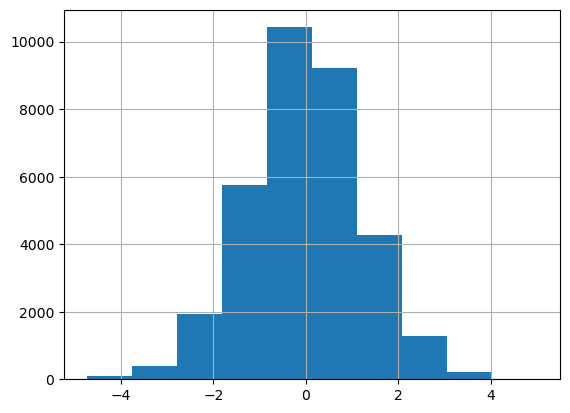

In [51]:
lag_mom_z.hist(bins=10)

In [ ]:
def laguerre_filter(series, alpha=0.4):
    gamma = 1- alpha
    L0= L1= L2= L3= series.iloc[0]
    filt = []
    
    for p in series:
        L0_ = (1 - gamma) * p + gamma * L0
        L1_ = -gamma * L0_ + L0 + gamma * L1
        L2_ = -gamma * L1_ + L1 + gamma * L2
        L3_= -gamma * L2_ + L2 + gamma * L3
        filt.append(((L0_ + 2*L1_ + 2*L2_ + L3_) / 6))
        L0, L1, L2, L3 = L0_, L1_, L2_, L3_
    return pd.Series(filt, index=series.index)

# 用法示例
df['tp'] = (df['high'] + df['low'] + df['close']) / 3
df['lag_price'] = laguerre_filter(df['tp'], 0.4)

In [18]:
df['lag_mom'] = df['lag_price'].pct_change(5)

In [22]:
df['lag_mom_z'] = (df['lag_mom']-df['lag_mom'].rolling(55).mean())/df['lag_mom'].rolling(55).std()

In [24]:
df = df.drop('lag_mon_z', axis=1)

### 信息系数 IC: Information Coefficient
IC衡量因子与未来收益的秩相关性（Spearman相关）。
IC值越高（>0），表示因子越能预测未来收益。

In [40]:
df['ret_5'] = df['close'].shift(-5)/df['close']-1
df['ret_8'] = df['close'].shift(-8)/df['close']-1
df['ret_13'] = df['close'].shift(-13)/df['close']-1

In [32]:
from scipy.stats import spearmanr, pearsonr

ic_spearman = df[['lag_mom_z', 'ret_5']].dropna()
ic_val, ic_p = spearmanr(ic_spearman['lag_mom_z'], ic_spearman['ret_5'])

print(f"Spearman IC: {ic_val:.4f}, p-value: {ic_p:.4f}")
ic_ret_1 = df.lag_mom_z.corr(df.ret_5, method='spearman')
print(f'和5个周期之后的收益率相关性为{ic_ret_1}')

Spearman IC: 0.0000, p-value: 0.9935
和5个周期之后的收益率相关性为4.4465920092157874e-05


### 分组收益( 分箱回测)

C:\Users\xlfin\AppData\Local\Temp\ipykernel_33568\400171403.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_by_bin = df_tmp.groupby('bin').apply(


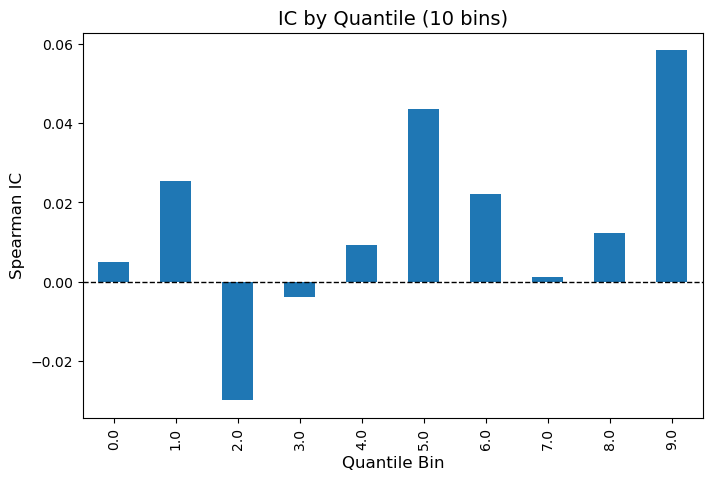

In [45]:
# df['q'] = pd.qcut(df['lag_mom_z'], 5, labels=False)

# 分箱处理( 等分位数分箱) 
# 探究因子在哪个范围与label的相关性最高(有更好的预测能力)
bins = pd.qcut(df['lag_mom_z'], q=10, labels=False, duplicates='drop')
# create a df 方便操作
df_tmp = pd.DataFrame({
    'lag_mom_z': df['lag_mom_z'],
    'ret_8': df['ret_8'],
    'bin': bins
})

ic_by_bin = df_tmp.groupby('bin').apply(
    lambda g:g['lag_mom_z'].corr(g['ret_8'], method='spearman')
)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
ic_by_bin.plot(kind='bar')

plt.title('IC by Quantile (10 bins)', fontsize=14)
plt.xlabel('Quantile Bin', fontsize=12)
plt.ylabel('Spearman IC', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.show()


### T test (验证收益差显著性)

In [46]:
import scipy.stats as st

df['q'] = pd.qcut(df['lag_mom_z'], 10, labels=False)

# 拿高分位组(Q8, Q10) vs 低分位组(Q0, Q2)
high = df.loc[df['q'] >= 8, 'ret_8']
high= high.dropna()
low  = df.loc[df['q'] <= 2, 'ret_8']
low = low.dropna()

t, p = st.ttest_ind(high, low, equal_var=False)
print(f"高低组收益T检验: T={t:.4f}, P={p:.4f}")

# 结论：
# 在 99% 的置信区间下（P < 0.01），我们可以认为：
# 高动量组的平均未来收益显著高于低动量组。

高低组收益T检验: T=2.7207, P=0.0065


### 构建多空组合

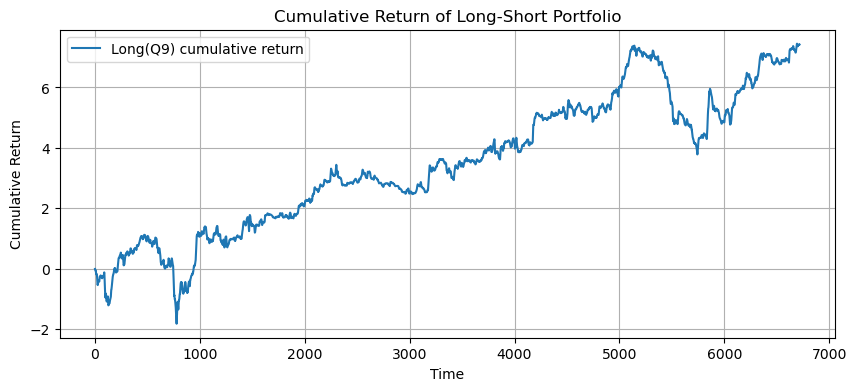

In [47]:
long_ret = df.loc[df['q'] >= 8, 'ret_8']
plt.figure(figsize=(10,4))
plt.plot(np.nancumsum(long_ret), label='Long(Q9) cumulative return')
plt.title('Cumulative Return of Long-Short Portfolio')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

#### 确定分位数阈值

quantile_bins = df.loc[:train_end, 'lag_mom_z'].quantile(np.linspace(0, 1, 11))